<a href="https://colab.research.google.com/github/agungdaus/data-science-2026/blob/main/Pertemuan10_Agung_Firdaus_240401010258.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#info

---




```
NAMA  : AGUNG FIRDAUS

NIM   : 240401010258

KELAS : IF403
```





In [3]:
import kagglehub
import pandas as pd
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(path)
df = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
print(df["Churn"].value_counts(normalize=True))

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
/kaggle/input/telco-customer-churn
(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [4]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Bersihkan TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])
df = df.drop(columns=["customerID"])

# Target
y = df["Churn"].map({"Yes": 1, "No": 0})

# Fitur + encoding
X = df.drop(columns=["Churn"])
X = pd.get_dummies(X, drop_first=True)

# Split dengan stratify (penting untuk imbalanced dataset!)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [5]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC Score: 0.8199


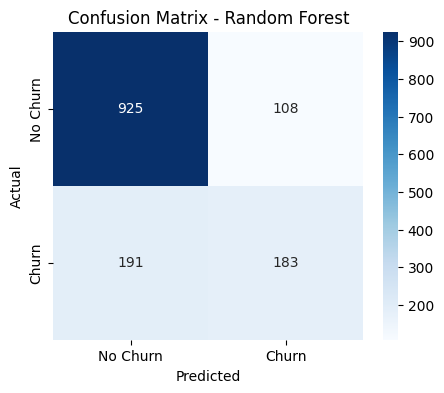

In [6]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Prediksi & probabilitas dari model yang sudah dilatih di step 3 ---
y_pred = rf.predict(X_te)
y_proba = rf.predict_proba(X_te)[:, 1]

# --- Classification Report ---
print("=== Classification Report ===")
print(classification_report(y_te, y_pred, target_names=["No Churn", "Churn"]))

# --- ROC-AUC ---
roc_auc = roc_auc_score(y_te, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# --- Confusion Matrix (heatmap) ---
cm = confusion_matrix(y_te, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [8]:
# --- Hitung probabilitas churn ---
y_proba = rf.predict_proba(X_te)[:, 1]

# Contoh penerapan bisnis: tampilkan 10 pelanggan dengan risiko churn tertinggi
risk_df = X_te.copy()
risk_df["Probabilitas_Churn"] = y_proba
risk_df["Aktual_Churn"] = y_te.values

top_risk = risk_df.sort_values("Probabilitas_Churn", ascending=False).head(10)
print("=== 10 Pelanggan dengan Risiko Churn Tertinggi ===")
print(top_risk[["Probabilitas_Churn", "Aktual_Churn"]])

=== 10 Pelanggan dengan Risiko Churn Tertinggi ===
      Probabilitas_Churn  Aktual_Churn
1731            1.000000             1
1739            0.996667             1
2927            0.996667             0
684             0.996667             0
809             0.996667             1
3682            0.990000             1
1144            0.983333             1
2631            0.970000             1
3380            0.963333             1
4484            0.960000             0


**KESIMPULAN**


Model Random Forest cukup efektif memprediksi churn pelanggan, dengan ROC-AUC yang menunjukkan kemampuan diskriminasi yang baik antara pelanggan churn dan tidak churn. Karena dataset bersifat imbalanced, metrik Recall pada kelas Churn menjadi fokus utama dibanding akurasi, agar sebanyak mungkin pelanggan berisiko churn dapat terdeteksi untuk program retensi. Model ini bisa dimanfaatkan secara praktis untuk memprioritaskan pelanggan dengan probabilitas churn tertinggi, sehingga upaya dan biaya retensi perusahaan dapat dialokasikan secara lebih tepat sasaran.


**Interpretasi**

Untuk kasus customer churn yang imbalanced, metrik yang paling relevan adalah Recall dan F1-Score pada kelas Churn, bukan Accuracy.

Kenapa: Accuracy bisa menyesatkan karena distribusi kelas timpang (mayoritas "No Churn") — model yang malas menebak "No Churn" untuk semua orang saja sudah dapat accuracy tinggi tanpa berguna. Recall penting karena tujuan bisnisnya adalah menangkap sebanyak mungkin pelanggan yang benar-benar akan churn, supaya tim retensi bisa intervensi lebih dulu; recall rendah berarti banyak pelanggan berisiko lolos tak terdeteksi. F1-Score menyeimbangkan recall dengan precision, supaya model tidak terlalu agresif menandai orang sebagai "akan churn" (yang bisa boros budget promo retensi).